(2000,) (2000, 3) (2000,)
(1000,) (1000, 3)
Potential at x=0.1:  158.78728


[MESSAGE] ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━��━━━━━━━━━━━━━━━━━┓
[MESSAGE] ╻ ╻┏━┓┏┳┓┏┳┓╺┳┓
[MESSAGE] ┃ ┃┣━┫┃┃┃┃┃┃ ┃┃ Version: 2.5
[MESSAGE] ┗━┛╹ ╹╹ ╹╹ ╹╺┻┛
[MESSAGE] Compiled at: Mar 23 2026 16:37:01
[MESSAGE] Compiled in single precision mode
[MESSAGE] Computation started at Mon Mar 23 16:41:15 2026

[MESSAGE] [System] CUDA initialized
[MESSAGE] [System] Using device: NVIDIA GeForce RTX 4070 Ti with id: 0
[MESSAGE] [System] Compute capability of the device: 8.9
[MESSAGE] ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ 
[MESSAGE] [ParticleData] Created with 2000 particles.
[MESSAGE] [ParticleGroup] Group All created with All selector
[MESSAGE] [ParticleGroup] Group All contains 2000 particles.
[MESSAGE] [Interactor] IBM::CustomPoisson created.
[MESSAGE] [Interactor] Acting on group All
[MESSAGE] [CustomPoisson] Proposed h: 5.00067
[MESSAGE] [CustomPoisson] Selected h: 5
[MESSAGE] [CustomPoisson] tolerance: 0.001
[MESSAGE] [CustomPoisson] support: 6
[MESSAGE] [CustomPo

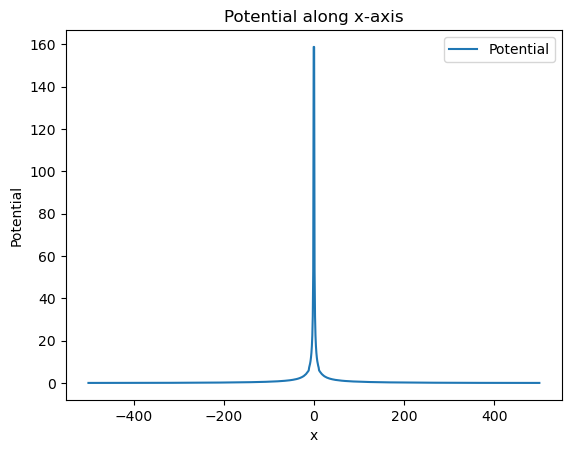

317.5773 -317.5773


In [17]:
import libPoisson as lb
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
eps = 1.0

# Create a charge in the center of the domain
n_sources = int(1e3)
n_targets = int(1e3)
solver = lb.uammdPSE(permittivity=eps, charge_radius=0.1, periodicityX="periodic", periodicityY="periodic", periodicityZ="periodic",
                     Lx=1000.0, Ly=1000.0, Lz=1000.0, split=0.1)
source_pos = cp.array([[0.0, 0.0, 0.0]]*n_sources).flatten()
source_charge = cp.array([1.0]*n_sources)
target_x = cp.linspace(-500.0, 500.0, n_targets)
target_y = cp.zeros_like(target_x)
target_z = cp.zeros_like(target_x)
target_pos = cp.stack((target_x, target_y, target_z), axis=-1).flatten()

phi, E = solver(source_pos, target_pos, source_charge)
print(np.shape(phi), np.shape(E))
print("Potential at x=0.1: ", phi[int(n_targets/2)])
x = target_pos.reshape(-1,3)[:,0].get()
Ex = E.reshape(-1,3)[:,0]
plt.plot(x, phi, '-', label='Potential')
#plt.plot(x, n_sources*np.sign(x)/(4*np.pi*eps*x), 'r--', label='1/x')
#plt.vlines(0.1, np.min(Ex)*1.1, np.max(Ex)*1.1, colors='k', linestyles='dashed')
#plt.ylim(np.min(phi)*1.1, np.max(phi)*1.1)
plt.xlabel('x')
plt.ylabel('Potential')
plt.title('Potential along x-axis')
plt.legend()
plt.show()
print(np.max(Ex), np.min(Ex))

In [ ]:
# check performance
import libPoisson as lb
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import time
timer_blocked = []
timer_unblocked = []
samples = 1
N_SAMPLES = np.logspace(5, 5, num=1, dtype=int)
n_targets = 1
eps = 4.0
solver_blocked = lb.NBody(permittivity=eps, charge_radius=0.1, periodicityX="open", periodicityY="open", periodicityZ="open")
n_sources = N_SAMPLES[-1]
source_pos = cp.array([[0.0, 0.0, 0.0]]*n_sources).flatten()
source_charge = cp.array([1.0]*n_sources)
target_x = cp.linspace(-1.0, 1.0, n_targets)
target_y = cp.zeros_like(target_x)
target_z = cp.zeros_like(target_x)
target_pos = cp.stack((target_x, target_y, target_z), axis=-1).flatten()
for n_sources in N_SAMPLES:
    blocked = 0
    unblocked = 0
    for _ in range(samples):
        a = time.time()
        #phi, E = solver(source_pos, target_pos, source_charge)
        unblocked += time.time() - a
        a = time.time()
        solver_blocked(source_pos, source_pos, source_charge)
        cp.cuda.Stream.null.synchronize()
        blocked += time.time() - a
    timer_blocked.append(blocked/samples)
    timer_unblocked.append(unblocked/samples)
#plt.plot(N_SAMPLES, timer_unblocked, label="Unblocked")
plt.plot(np.logspace(2,5,num=1, dtype=int),timer_blocked,'o', label="Blocked")
plt.xlabel("Number of Targets")
plt.ylabel("Time (seconds)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

shapes: (35,) (35, 3)


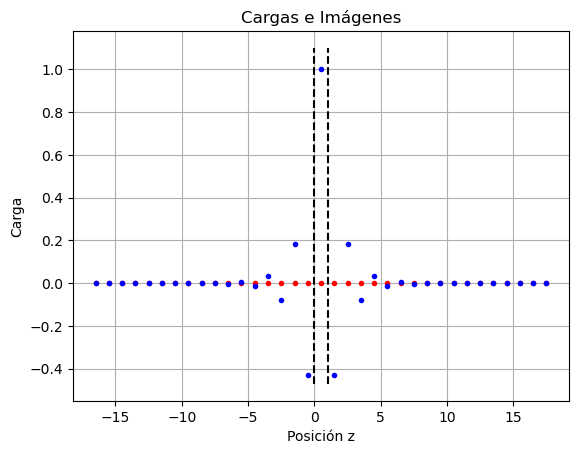

In [185]:
import numpy as np
import matplotlib.pyplot as plt
def generar_imagenes_3d(eps1, eps2, eps3, z1, z2, cargas, posiciones, n_rebotes):
    """
    Genera todas las imágenes hasta n_rebotes para posiciones 3D (N,3),
    usando el método de reflexiones múltiples entre dos planos.
    
    Parámetros:
    - eps1, eps2, eps3: permitividades
    - z1, z2: posiciones de los planos
    - cargas: array (N,)
    - posiciones: array (N,3)
    
    Devuelve:
    - cargas_ext: array de cargas incluyendo imágenes
    - posiciones_ext: array de posiciones (M,3) incluyendo imágenes
    """
    cargas = np.atleast_1d(cargas)
    posiciones = np.atleast_2d(posiciones)
    N = cargas.shape[0]

    # Coeficientes de reflexión
    r12 = (eps2 - eps1) / (eps2 + eps1)
    r23 = (eps2 - eps3) / (eps2 + eps3)

    # Cargas y posiciones originales
    cargas_ext = cargas.copy()
    posiciones_ext = posiciones.copy()

    if n_rebotes == 0:
        return cargas_ext, posiciones_ext

    # Array de rebotes: 1..n
    n_array = np.arange(1, n_rebotes + 1)[:, np.newaxis]  # (n_rebotes,1)

    # Potencias de los coeficientes
    n_array_even = np.ceil(n_array/2)
    n_array_odd = n_array-n_array_even
    r12_pot = r12 ** n_array_even * r23 ** n_array_odd  # (n_rebotes,1)
    r23_pot = r23 ** n_array_even * r12 ** n_array_odd

    # Replicar cargas y z originales para broadcasting
    cargas_rep = cargas[np.newaxis, :]  # (1, N)
    z_orig = posiciones[:, 2][np.newaxis, :]  # (1,N)
    xy = posiciones[:, :2]  # (N,2) -> se mantiene constante

    # Reflejo en z1
    q_im1 = cargas_rep * r12_pot  # (n_rebotes, N)
    z_im1 = 2*n_array_even*z1 - 2*n_array_odd*z2 + (-1)**n_array * z_orig

    # Reflejo en z2
    q_im2 = cargas_rep * r23_pot
    z_im2 = 2*n_array_even*z2 - 2*n_array_odd*z1 + (-1)**n_array * z_orig

    # Construir posiciones 3D
    xy_repeat = np.tile(xy, (n_rebotes, 1))  # (n_rebotes*N,2)
    z_im1_flat = z_im1.ravel()
    z_im2_flat = z_im2.ravel()

    pos_im1 = np.hstack([xy_repeat, z_im1_flat[:, np.newaxis]])  # (n_rebotes*N,3)
    pos_im2 = np.hstack([xy_repeat, z_im2_flat[:, np.newaxis]])

    # Flatten cargas
    q_im1_flat = q_im1.ravel()
    q_im2_flat = q_im2.ravel()

    # Concatenar con originales
    cargas_ext = np.concatenate([cargas_ext, q_im1_flat, q_im2_flat])
    posiciones_ext = np.concatenate([posiciones_ext, pos_im1, pos_im2])

    return cargas_ext, posiciones_ext

def convergence_criterion(eps1, eps2, eps3, tol=1e-3):
    """
    https://chatgpt.com/c/69c2733b-5610-8332-a53a-f9560a27a8e6
    """
    r12 = (eps2 - eps1) / (eps2 + eps1)
    r23 = (eps2 - eps3) / (eps2 + eps3)
    r = np.sqrt(np.real(np.abs(r12*r23)))
    if r == 0:
        return 0
    if r == 1:
        return int(1/(2*tol))
    lntol = np.log(1/tol)
    lnr = np.log(1/r)
    N = int(min(np.ceil(lntol/lnr), 1/(2*tol)))
    return N

eps1 = 2.5
eps2 = 1.0
eps3 = 2.5
z1 = 0.0
z2 = 1.0
cargas = np.array([1.0])
posiciones = np.zeros((1,3))
posiciones[:,0] = np.array([0.0])
posiciones[:,1] = np.array([0.0])
posiciones[:,2] = np.array([0.5])
n_rebotes = convergence_criterion(eps1, eps2, eps3, tol=1e-6)
cargas_ext, posiciones_ext = generar_imagenes_3d(eps1, eps2, eps3, z1, z2, cargas, posiciones, n_rebotes)
print("shapes:", cargas_ext.shape, posiciones_ext.shape)
plt.plot(posiciones_ext[:,2], np.imag(cargas_ext), '.r')
plt.plot(posiciones_ext[:,2], np.real(cargas_ext), '.b')
plt.vlines(z1, np.min(np.real(cargas_ext))*1.1, np.max(np.real(cargas_ext))*1.1, colors='k', linestyles='dashed')
plt.vlines(z2, np.min(np.real(cargas_ext))*1.1, np.max(np.real(cargas_ext))*1.1, colors='k', linestyles='dashed')
plt.xlabel('Posición z')
plt.ylabel('Carga')
plt.title('Cargas e Imágenes')
plt.grid()